# 🧠 DreamScape AI — NLP Motif Extraction (Deliverable 3)

This notebook refines the Deliverable 2 NLP pipeline for **DreamScape AI**:

- Loads the cleaned **DreamBank** dataset safely (even if the JSON shape is weird).
- Computes **Sentence-BERT** embeddings for dream texts.
- Applies **K-Means** (baseline) and **HDBSCAN** (refined) clustering to discover motifs.
- Extracts **TF-IDF keywords** per cluster.
- Visualizes **embedding space, clusters, and emotion distributions**.
- Saves updated artifacts for Deliverable 3.

In [1]:
# -------------------------------------------------------------
# Imports
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer

import hdbscan  # make sure: pip install hdbscan

In [2]:
# -------------------------------------------------------------
# Paths
# -------------------------------------------------------------
BASE = Path("..").resolve() if Path(".").name == "notebooks" else Path(".").resolve()
DATA_PROC = BASE / "data" / "processed"
RESULTS = BASE / "results"

RESULTS.mkdir(parents=True, exist_ok=True)

print("BASE:     ", BASE)
print("DATA_PROC:", DATA_PROC)
print("RESULTS:  ", RESULTS)

BASE:      /Users/saturnine/Dreamscape/notebooks
DATA_PROC: /Users/saturnine/Dreamscape/notebooks/data/processed
RESULTS:   /Users/saturnine/Dreamscape/notebooks/results


## 1. Load Cleaned DreamBank (Robust Loader for Deliverable 3)

In Deliverable 2, `dreambank_clean.json` loaded cleanly as a 1,000-row DataFrame.

After some processing, the file can sometimes end up in a **(1, 1000)** shape,  
where each cell in that single row is a full dream record (a `dict`).

This loader:

1. Reads the JSON with `pandas`.
2. Detects if we have a **single row of many dicts** (shape `(1, 1000)`).
3. Reshapes it back into a proper **(N, columns)** DataFrame.
4. Renames the dream text column to `text` so downstream code is stable.

In [3]:
# -------------------------------------------------------------
# Helper: robust loader for dreambank_clean.json
# -------------------------------------------------------------
def load_cleaned_dreambank(path: Path) -> pd.DataFrame:
    df = pd.read_json(path)
    print("Raw loaded shape:", df.shape)
    print("Columns:", list(df.columns)[:10], "..." if df.shape[1] > 10 else "")

    # Case 1: 1 row, many columns, each cell is a dict → reshape
    if df.shape[0] == 1 and df.shape[1] > 1:
        row_vals = df.iloc[0].tolist()
        if all(isinstance(x, dict) for x in row_vals):
            print("Detected single-row DataFrame with dicts in each column → reshaping.")
            df = pd.DataFrame(row_vals)
            print("Reshaped to:", df.shape)

    # Case 2: 1 row, 1 column, that cell is a list of dicts → reshape
    if df.shape == (1, 1):
        cell_val = df.iloc[0, 0]
        if isinstance(cell_val, list) and len(cell_val) > 0 and isinstance(cell_val[0], dict):
            print("Detected list-of-dicts inside a single cell → reshaping.")
            df = pd.DataFrame(cell_val)
            print("Reshaped to:", df.shape)

    # Identify text column
    candidates = ["text", "report", "dream_text", "dream"]
    text_col = None
    for c in candidates:
        if c in df.columns:
            text_col = c
            break

    if text_col is None:
        raise KeyError(f"No text-like column found. Checked: {candidates}")

    if text_col != "text":
        df = df.rename(columns={text_col: "text"})

    # Basic cleaning
    df = df[df["text"].notna()].copy()
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"].str.len() > 50].copy()  # drop very short ones (refinement vs D2)

    print("After cleaning, records:", len(df))
    return df

In [4]:
# -------------------------------------------------------------
# Load dataset
# -------------------------------------------------------------
clean_path = DATA_PROC / "dreambank_clean.json"
df = load_cleaned_dreambank(clean_path)

print("\nSample rows:")
df.head(2)

Raw loaded shape: (1000, 12)
Columns: ['id', 'name', 'number', 'time', 'date', 'gender', 'age', 'text', 'character', 'emotion'] ...
After cleaning, records: 1000

Sample rows:


,id,name,number,time,date,gender,age,text,character,emotion,text_len,word_count
0,dorothea,Dorothea: 53 years of dreams,737,1912-1965,11/--/63,F,A,I fixed my plate with rice and meat paste then...,"1ISC, 1FSA, 1FSA, 1ISA",None,536,109
1,bea1,Bea 1: a high school student,092,2003-2005,01/05/2004 (age 15),F,T,I dreamed that I had to reorganize the periodi...,None,None,178,35


## 2. Light Text Preprocessing (Stable Across D2 and D3)

We keep preprocessing deliberately light to preserve the narrative voice of dreams:

- Convert text to lowercase.
- Strip extra whitespace.
- Keep punctuation (diffusion prompts and transformers can benefit from it).

In [5]:
# -------------------------------------------------------------
# Simple, stable preprocessing
# -------------------------------------------------------------
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    return s.strip()

df["text_clean"] = df["text"].apply(clean_text)

print("Example cleaned text:\n")
print(df["text"].iloc[0][:300], "\n---\n", df["text_clean"].iloc[0][:300])

Example cleaned text:

I fixed my plate with rice and meat paste then began to play cards. One person was missing. "Whose turn?" I am No. 8 so it must be one's. "She's gone." A baby calls her mother. "You play this hand and I'll take her turn next." The older woman sits down and begins to shuffle cards, two decks together 
---
 i fixed my plate with rice and meat paste then began to play cards. one person was missing. "whose turn?" i am no. 8 so it must be one's. "she's gone." a baby calls her mother. "you play this hand and i'll take her turn next." the older woman sits down and begins to shuffle cards, two decks together


## 3. Sentence-BERT Embeddings (Updated for D3)

We reuse the **Sentence-BERT** model from Deliverable 2:

- Model: `sentence-transformers/all-MiniLM-L6-v2`
- Output dim: 384
- Output:
  - `dream_embeddings.npy` (overwrites D2 file with refined set)
  - Column `embedding` in the DataFrame

In [6]:
# -------------------------------------------------------------
# Sentence-BERT Embeddings
# -------------------------------------------------------------
model_name = "sentence-transformers/all-MiniLM-L6-v2"
sbert = SentenceTransformer(model_name)

tqdm.pandas(desc="Embedding dreams (D3)")
df["embedding"] = df["text_clean"].progress_apply(
    lambda x: sbert.encode(x, show_progress_bar=False)
)

embeddings = np.vstack(df["embedding"].values)
print("Embedding matrix shape:", embeddings.shape)

# Save (same filename as D2 for continuity)
np.save(DATA_PROC / "dream_embeddings.npy", embeddings)

Embedding dreams (D3): 100%|████████████████| 1000/1000 [00:11<00:00, 87.87it/s]

Embedding matrix shape: (1000, 384)


## 4. Dimensionality Reduction for Visualization

To visualize the semantic structure:

1. First apply **PCA → 50 components** (stabilizes t-SNE).
2. Then run **t-SNE → 2D** for plotting.
3. Save a Deliverable-3 specific plot: `nlp_tsne_d3.png`.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


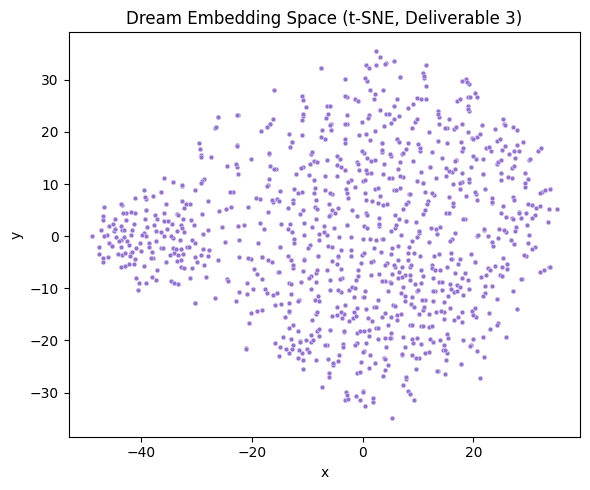

In [7]:
# -------------------------------------------------------------
# PCA + t-SNE
# -------------------------------------------------------------
pca = PCA(n_components=50, random_state=42)
emb_pca = pca.fit_transform(embeddings)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, max(5, len(df)//20)),  # adaptive for dataset size
    init="random",
    learning_rate="auto"
)
emb_2d = tsne.fit_transform(emb_pca)

df["x"], df["y"] = emb_2d[:, 0], emb_2d[:, 1]

plt.figure(figsize=(6, 5))
sns.scatterplot(x="x", y="y", data=df, s=12, color="mediumpurple")
plt.title("Dream Embedding Space (t-SNE, Deliverable 3)")
plt.tight_layout()
plt.savefig(RESULTS / "nlp_tsne_d3.png", dpi=150)
plt.show()

## 5. Motif Clustering — K-Means (Baseline) + HDBSCAN (Refinement)

We now apply two clustering strategies:

- **K-Means (k = 8)**  
  Baseline from Deliverable 2, good for fixed motif count.

- **HDBSCAN**  
  Density-based, automatically finds dense motif regions and labels outliers as `-1`.

Both will be saved so we can compare structure and use either for downstream analysis.

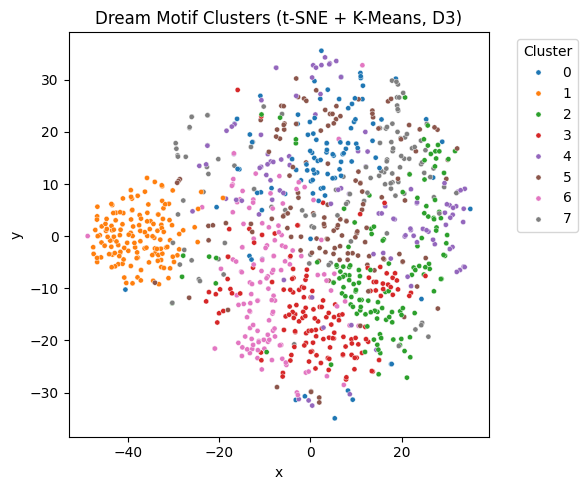

In [8]:
# -------------------------------------------------------------
# K-Means baseline clustering
# -------------------------------------------------------------
N_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto").fit(embeddings)
df["cluster_kmeans"] = kmeans.labels_

plt.figure(figsize=(6, 5))
sns.scatterplot(
    x="x",
    y="y",
    hue="cluster_kmeans",
    palette="tab10",
    data=df,
    s=14
)
plt.title("Dream Motif Clusters (t-SNE + K-Means, D3)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS / "nlp_clusters_kmeans_d3.png", dpi=150)
plt.show()

/opt/anaconda3/envs/dreamscape/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/dreamscape/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN labels (unique): [np.int64(-1)]


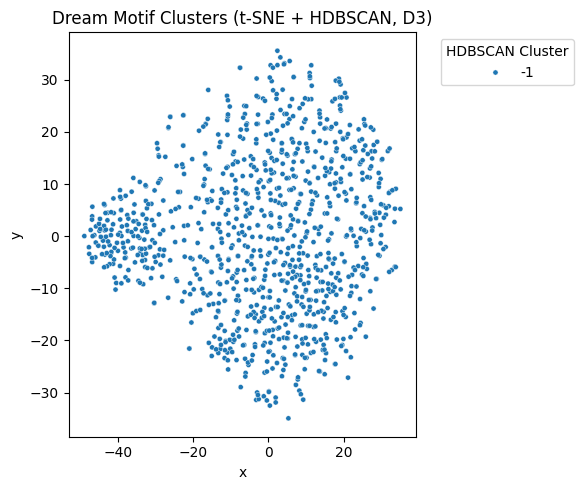

In [9]:
# -------------------------------------------------------------
# HDBSCAN refined clustering
# -------------------------------------------------------------
hdb = hdbscan.HDBSCAN(
    min_cluster_size=25,   # can tune
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom"
)
hdb_labels = hdb.fit_predict(embeddings)
df["cluster_hdbscan"] = hdb_labels

print("HDBSCAN labels (unique):", sorted(df["cluster_hdbscan"].unique()))

plt.figure(figsize=(6, 5))
sns.scatterplot(
    x="x",
    y="y",
    hue="cluster_hdbscan",
    palette="tab20",
    data=df,
    s=14
)
plt.title("Dream Motif Clusters (t-SNE + HDBSCAN, D3)")
plt.legend(title="HDBSCAN Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS / "nlp_clusters_hdbscan_d3.png", dpi=150)
plt.show()

## 6. Motif Keyword Extraction (Per Cluster)

We compute **TF-IDF keywords** per cluster to label motifs:

- Use `TfidfVectorizer` with English stopwords.
- For each cluster:
  - Compute mean TF-IDF scores.
  - Keep the **top 10 keywords**.
- Save:
  - `cluster_keywords_kmeans_d3.json`
  - `cluster_keywords_hdbscan_d3.json`

In [10]:
# -------------------------------------------------------------
# TF-IDF keyword extraction
# -------------------------------------------------------------
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
X = vectorizer.fit_transform(df["text_clean"])
terms = np.array(vectorizer.get_feature_names_out())

def extract_keywords(labels, label_name: str, top_k: int = 10):
    out = {}
    for c in sorted(set(labels)):
        if c == -1 and label_name == "cluster_hdbscan":
            # HDBSCAN noise cluster
            continue
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue
        mean_tfidf = np.asarray(X[idx].mean(axis=0)).flatten()
        top_idx = mean_tfidf.argsort()[-top_k:][::-1]
        out[int(c)] = terms[top_idx].tolist()
    return out

cluster_keywords_kmeans = extract_keywords(df["cluster_kmeans"].values, "cluster_kmeans")
cluster_keywords_hdbscan = extract_keywords(df["cluster_hdbscan"].values, "cluster_hdbscan")

print("K-Means motif keywords:")
for c, words in cluster_keywords_kmeans.items():
    print(f"  Cluster {c}: {', '.join(words)}")

print("\nHDBSCAN motif keywords (excluding noise):")
for c, words in cluster_keywords_hdbscan.items():
    print(f"  Cluster {c}: {', '.join(words)}")

# Save
with open(DATA_PROC / "cluster_keywords_kmeans_d3.json", "w") as f:
    json.dump(cluster_keywords_kmeans, f, indent=2)

with open(DATA_PROC / "cluster_keywords_hdbscan_d3.json", "w") as f:
    json.dump(cluster_keywords_hdbscan, f, indent=2)

K-Means motif keywords:
  Cluster 0: br, work, old, taking, trying, room, like, table, just, long
  Cluster 1: dream, br, remember, dreamed, dreamt, going, woke, like, td, went
  Cluster 2: said, like, went, got, came, room, people, house, going, water
  Cluster 3: said, got, went, guy, car, saw, man, house, room, police
  Cluster 4: br, bus, like, man, road, riding, long, going, looking, driving
  Cluster 5: said, like, went, br, people, didn, man, just, going, room
  Cluster 6: ezra, mom, went, said, school, dad, like, guy, people, shop
  Cluster 7: says, like, br, woman, house, girl, say, man, comes, mary

HDBSCAN motif keywords (excluding noise):


## 7. Emotion Distribution per Motif Cluster

We reuse the HVdC emotion codes to see how **affect** is distributed across clusters.

- Extract 2-letter emotion codes using regex.
- Build a `(cluster × emotion)` table.
- Plot a heatmap to visually compare emotional profiles across motifs.

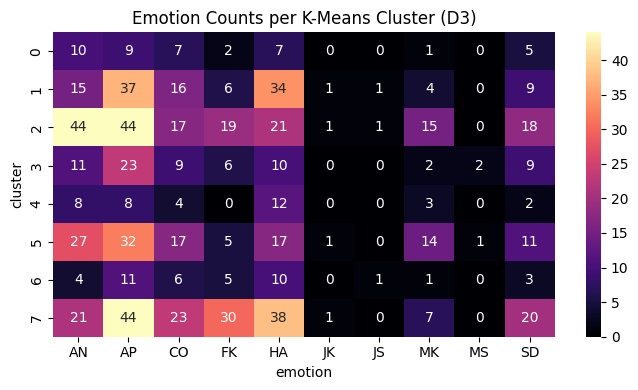

In [11]:
# -------------------------------------------------------------
# Emotion distribution per K-Means cluster
# -------------------------------------------------------------
def extract_emotions(val):
    if pd.isna(val):
        return []
    return re.findall(r"[A-Z]{2}", str(val))

if "emotion" in df.columns:
    df["emolist"] = df["emotion"].apply(extract_emotions)

    rows = []
    for _, row in df.iterrows():
        for e in row.get("emolist", []):
            rows.append({"cluster": row["cluster_kmeans"], "emotion": e})
    emo_df = pd.DataFrame(rows)

    if not emo_df.empty:
        emo_pivot = emo_df.pivot_table(
            index="cluster",
            columns="emotion",
            aggfunc=len,
            fill_value=0
        )

        plt.figure(figsize=(7, 4))
        sns.heatmap(emo_pivot, cmap="magma", annot=True, fmt="d")
        plt.title("Emotion Counts per K-Means Cluster (D3)")
        plt.tight_layout()
        plt.savefig(RESULTS / "nlp_emotion_heatmap_kmeans_d3.png", dpi=150)
        plt.show()
    else:
        print("No emotion tags available to plot.")
else:
    print("Column 'emotion' not found in df; skipping emotion heatmap.")

## 8. Summary of Deliverable 3 NLP Outputs

This notebook produced the following updated artifacts:

- **Embeddings**
  - `data/processed/dream_embeddings.npy` — semantic vectors (updated D3 run)

- **Clustering Visuals**
  - `results/nlp_tsne_d3.png` — embedding space visualization
  - `results/nlp_clusters_kmeans_d3.png` — K-Means clusters (k = 8)
  - `results/nlp_clusters_hdbscan_d3.png` — HDBSCAN clusters (noise-aware)

- **Motif Keywords**
  - `data/processed/cluster_keywords_kmeans_d3.json`
  - `data/processed/cluster_keywords_hdbscan_d3.json`

- **Emotion Profiles**
  - `results/nlp_emotion_heatmap_kmeans_d3.png`

These outputs directly support the **Extended Evaluation and Updated Results** section of Deliverable 3 and will be referenced in the final IEEE-style report and interface demo.